<a href="https://colab.research.google.com/github/prangancode/lane-detection-using-semantic-models-for-bd-complex-road-scenarios/blob/main/SegNet_lane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Google Drive

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Python libraries

In [ ]:
import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm



import albumentations as A
from albumentations.pytorch import ToTensorV2


from PIL import Image
import random

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Utility Function to Load Paths

In [ ]:
import os

def load_image_mask_paths(image_folder, mask_folder):
    """
    Loads image and mask file paths from their respective folders.

    Args:
        image_folder (str): Path to the folder containing images.
        mask_folder (str): Path to the folder containing masks.

    Returns:
        tuple: A tuple of (image_paths, mask_paths), both sorted lists of file paths.
    """
    image_paths = sorted([os.path.join(image_folder, fname) for fname in os.listdir(image_folder) if fname.endswith(('.jpg', '.png'))])
    mask_paths = sorted([os.path.join(mask_folder, fname) for fname in os.listdir(mask_folder) if fname.endswith(('.jpg', '.png'))])

    return image_paths, mask_paths

# Dataset Class

In [ ]:
class LaneDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and mask
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)  # Load as grayscale

        # Normalize image and mask
        image = image / 255.0
        mask = mask / 255.0

        # Convert to PIL for transforms
        image = Image.fromarray((image * 255).astype('uint8'))
        mask = Image.fromarray((mask * 255).astype('uint8'))

        # Apply transforms if specified
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            image = transforms.ToTensor()(image)
            mask = torch.as_tensor(np.array(mask), dtype=torch.float32).unsqueeze(0)

        return image, mask


# Transformations

In [ ]:
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import random
import torch
import numpy as np

class CustomTransform:
    def __init__(self, target_size=(256, 256), brightness=0.2, contrast=0.2, rotation=10, flip_prob=0.5, augment=True):
        """
        Custom transform class for lane detection.

        Args:
            target_size (tuple): The target size (height, width) for the image and mask.
            brightness (float): Brightness adjustment factor.
            contrast (float): Contrast adjustment factor.
            rotation (int): Maximum rotation angle (in degrees).
            flip_prob (float): Probability of horizontal flip.
            augment (bool): Whether to apply augmentations (True for training, False for testing).
        """
        self.target_size = target_size
        self.brightness = brightness
        self.contrast = contrast
        self.rotation = rotation
        self.flip_prob = flip_prob
        self.augment = augment
        self.image_transforms = T.Compose([
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize RGB channels
        ])

    def __call__(self, image, mask):
        """
        Apply augmentations to the image and mask.

        Args:
            image (PIL.Image): Input image.
            mask (PIL.Image): Corresponding binary mask.

        Returns:
            image (torch.Tensor): Transformed image.
            mask (torch.Tensor): Transformed binary mask.
        """
        if self.augment:
            # Random horizontal flip
            if random.random() < self.flip_prob:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Random rotation
            angle = random.uniform(-self.rotation, self.rotation)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

            # Random brightness and contrast adjustment
            image = TF.adjust_brightness(image, 1 + random.uniform(-self.brightness, self.brightness))
            image = TF.adjust_contrast(image, 1 + random.uniform(-self.contrast, self.contrast))

            # Random resized crop
            i, j, h, w = T.RandomResizedCrop.get_params(image, scale=(0.8, 1.0), ratio=(1.0, 1.0))
            image = TF.resized_crop(image, i, j, h, w, self.target_size)
            mask = TF.resized_crop(mask, i, j, h, w, self.target_size)
        else:
            # Resize to target size without augmentations
            image = TF.resize(image, self.target_size)
            mask = TF.resize(mask, self.target_size)

        # Convert to tensor and normalize
        image = self.image_transforms(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.float32).unsqueeze(0) / 255.0

        return image, mask


# Train and Validation Data Preparation

In [ ]:
# Replace these with the actual paths to your train and validation folders
train_image_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/train'
train_mask_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_train_truth_masks'
val_image_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/val'
val_mask_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_val_truth_masks'

# Load paths for train and validation data
train_images, train_masks = load_image_mask_paths(train_image_folder, train_mask_folder)
val_images, val_masks = load_image_mask_paths(val_image_folder, val_mask_folder)

# Define transform
transform = CustomTransform(target_size=(256, 256))

# Create datasets and data loaders

# train_dataset = LaneDataset(train_images, train_masks, transform=transform)

train_dataset = LaneDataset(train_images, train_masks, transform=CustomTransform(target_size=(256, 256), augment=True))

val_dataset = LaneDataset(val_images, val_masks, transform=CustomTransform(target_size=(256, 256), augment=True))

# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True,persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Model Initialization

## SegNet Model Initialization

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SegNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(SegNet, self).__init__()

        # Encoder layers (VGG-like)
        self.encoder1 = self.conv_block(input_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256, num_convs=3)
        self.encoder4 = self.conv_block(256, 512, num_convs=3)
        self.encoder5 = self.conv_block(512, 512, num_convs=3)

        # Decoder layers.
        self.decoder5 = self.conv_block(512, 512, num_convs=3)
        self.decoder4 = self.conv_block(512, 256, num_convs=3)
        self.decoder3 = self.conv_block(256, 128, num_convs=3)
        self.decoder2 = self.conv_block(128, 64)
        self.decoder1 = self.conv_block(64, output_channels, use_batch_norm=False, use_activation=False)

    def conv_block(self, in_channels, out_channels, num_convs=2, use_batch_norm=True, use_activation=True):
        """
        Create a convolutional block with `num_convs` convolutional layers, batch norm, and ReLU.
        """
        layers = []
        for _ in range(num_convs):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_batch_norm:
                layers.append(nn.BatchNorm2d(out_channels))
            if use_activation:
                layers.append(nn.ReLU(inplace=True))
            in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.encoder1(x)
        e1_p = F.max_pool2d(e1, kernel_size=2, stride=2)

        e2 = self.encoder2(e1_p)
        e2_p = F.max_pool2d(e2, kernel_size=2, stride=2)

        e3 = self.encoder3(e2_p)
        e3_p = F.max_pool2d(e3, kernel_size=2, stride=2)

        e4 = self.encoder4(e3_p)
        e4_p = F.max_pool2d(e4, kernel_size=2, stride=2)

        e5 = self.encoder5(e4_p)
        e5_p = F.max_pool2d(e5, kernel_size=2, stride=2)

        # Decoder
        d5 = F.interpolate(e5_p, scale_factor=2, mode='nearest')
        d5 = self.decoder5(d5)

        d4 = F.interpolate(d5, scale_factor=2, mode='nearest')
        d4 = self.decoder4(d4)

        d3 = F.interpolate(d4, scale_factor=2, mode='nearest')
        d3 = self.decoder3(d3)

        d2 = F.interpolate(d3, scale_factor=2, mode='nearest')
        d2 = self.decoder2(d2)

        d1 = F.interpolate(d2, scale_factor=2, mode='nearest')
        d1 = self.decoder1(d1)

        return torch.sigmoid(d1)  # Use sigmoid for binary segmentation

In [ ]:
model = SegNet(input_channels=3, output_channels=1)

# Train the model

## SegNet Model Train

In [ ]:
from tqdm import tqdm
import os
import torch
import torch.nn.functional as F

def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy and IoU for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        tuple: (pixel accuracy, IoU)
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    accuracy = (pred == target).float().mean()  # Pixel accuracy
    iou = (intersection / union) if union > 0 else 0.0  # IoU
    return accuracy.item(), iou.item()

def train_model(model, train_loader, val_loader, num_epochs, lr, patience):
    """
    Train the model with loss, pixel accuracy, IoU metrics, and early stopping.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    best_val_loss = float('inf')
    no_improvement_epochs = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_acc = 0.0
        train_iou = 0.0

        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        # Training loop with tqdm
        with tqdm(total=len(train_loader), desc="Training", leave=False) as pbar:
            for images, masks in train_loader:
                images, masks = images.to(device), masks.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, masks)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()

                # Calculate metrics
                acc, iou = calculate_metrics(outputs, masks)
                train_acc += acc
                train_iou += iou

                pbar.set_postfix({"Loss": loss.item()})
                pbar.update(1)

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_acc / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)

        print(f"Training Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_acc:.4f}, IoU: {avg_train_iou:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        val_iou = 0.0
        with torch.no_grad():
            with tqdm(total=len(val_loader), desc="Validation", leave=False) as pbar_val:
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                    val_loss += loss.item()

                    # Calculate metrics
                    acc, iou = calculate_metrics(outputs, masks)
                    val_acc += acc
                    val_iou += iou

                    pbar_val.update(1)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)

        print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_acc:.4f}, IoU: {avg_val_iou:.4f}")

        # Save best model and check early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improvement_epochs = 0
            print("Saving best model...")
            output_dir = '/content/drive/MyDrive/path_to_model'
            os.makedirs(output_dir, exist_ok=True)
            model_path = os.path.join(output_dir, 'segnet_lane_detection1.pt')
            torch.save(model.state_dict(), model_path)
        else:
            no_improvement_epochs += 1
            print(f"No improvement for {no_improvement_epochs} epoch(s).")

        if no_improvement_epochs >= patience:
            print("Early stopping triggered!")
            break



train_model(model, train_loader, val_loader, num_epochs=32, lr=0.0001, patience=5)


Epoch 1/32


Training Loss: 0.3110, Accuracy: 0.9801, IoU: 0.0037


Validation Loss: 0.1157, Accuracy: 0.9793, IoU: 0.0024
Saving best model...

Epoch 2/32


Training Loss: 0.0666, Accuracy: 0.9808, IoU: 0.0028


Validation Loss: 0.0427, Accuracy: 0.9794, IoU: 0.0019
Saving best model...

Epoch 3/32


...

Validation Loss: 0.0125, Accuracy: 0.9871, IoU: 0.6263
No improvement for 3 epoch(s).

Epoch 24/32


Training Loss: 0.0102, Accuracy: 0.9878, IoU: 0.6461


Validation Loss: 0.0132, Accuracy: 0.9870, IoU: 0.5814
No improvement for 4 epoch(s).

Epoch 25/32


Training Loss: 0.0098, Accuracy: 0.9878, IoU: 0.6530


Validation Loss: 0.0134, Accuracy: 0.9868, IoU: 0.5913
No improvement for 5 epoch(s).
Early stopping triggered!


# Test Data Preparation

In [ ]:
# Replace these with the actual paths to your test folders
test_image_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/test'
test_mask_folder = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_test_truth_masks'

# Load paths for test data
test_images, test_masks = load_image_mask_paths(test_image_folder, test_mask_folder)

# Create test dataset and data loader
# test_dataset = LaneDataset(test_images, test_masks, transform=CustomTransform(target_size=(512, 512)))


test_dataset = LaneDataset(test_images, test_masks, transform=CustomTransform(target_size=(256, 256), augment=False))


test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Visualization of the model

## Segnet Model Visualization

**```model``` : ``` segnet_lane_detection1 ```**

<ipython-input-12-eeeccbaeb8ed>:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/path_to_model/segnet_lane_detectio

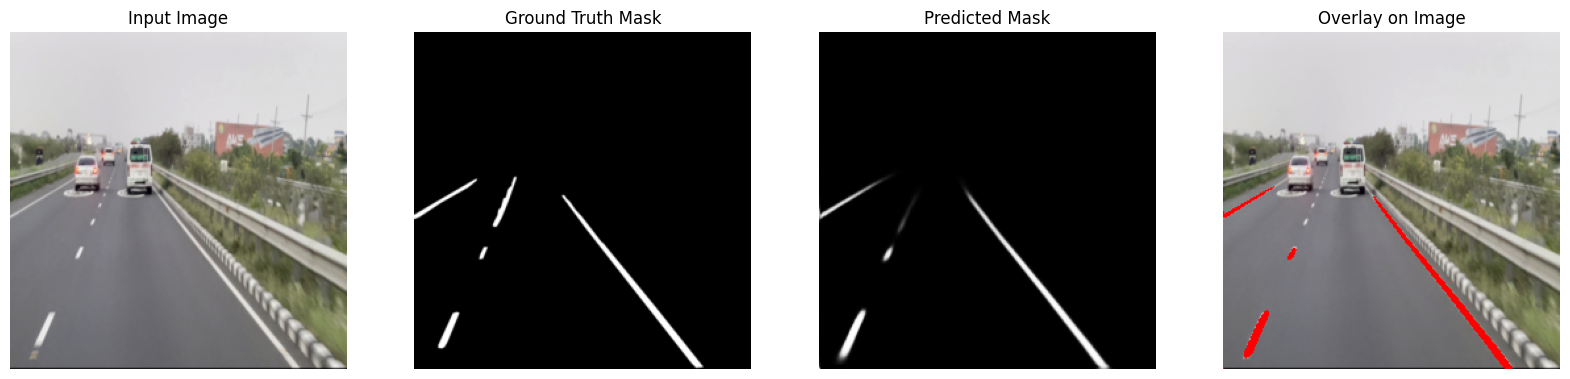

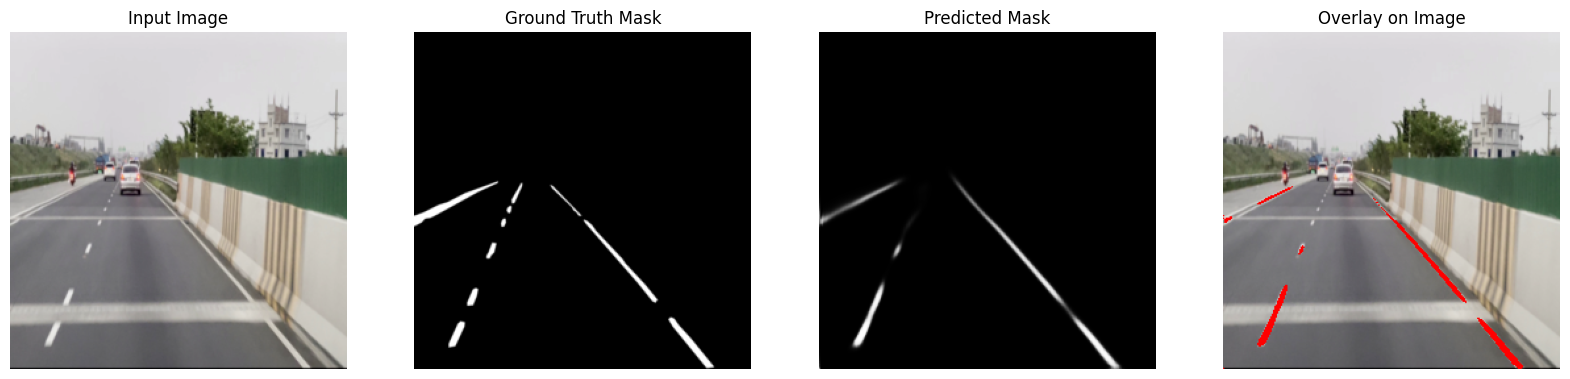

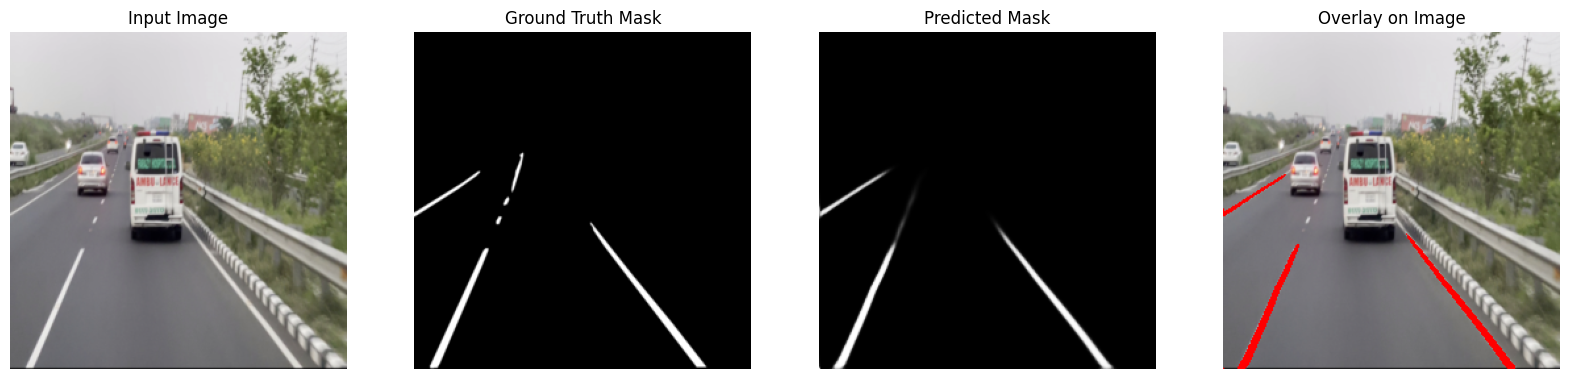

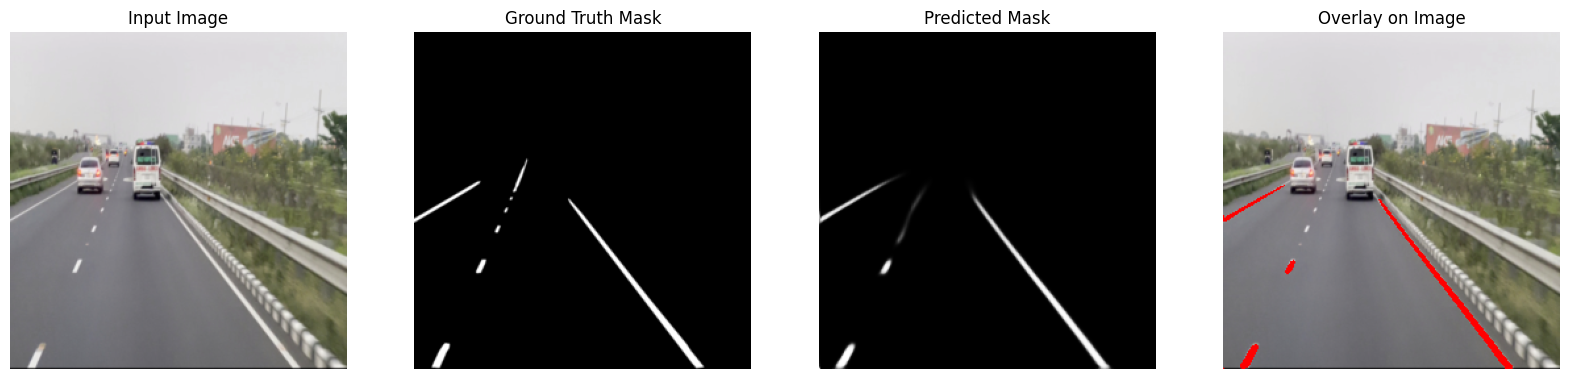

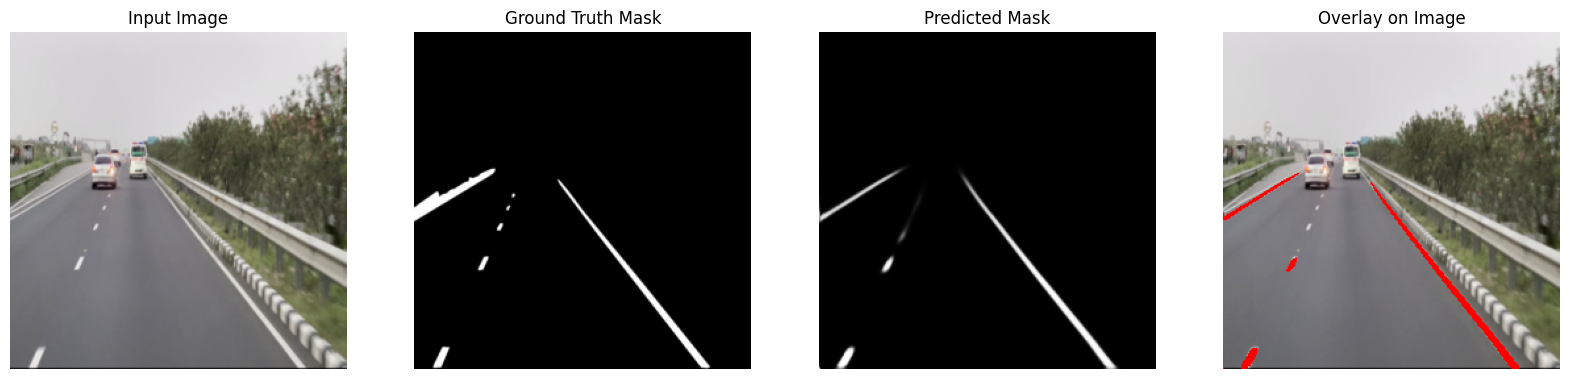

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, num_samples=3):
    """
    Visualizes predictions with input image, ground truth mask, predicted mask, and overlay.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    with torch.no_grad():
        samples_shown = 0
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    return

                # Input Image (convert from tensor to numpy for visualization)
                image = images[i].cpu().numpy()  # Convert to NumPy
                image = image.transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
                image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0, 1]

                # Ground Truth Mask
                mask = masks[i].cpu().squeeze().numpy()

                # Predicted Mask
                pred = outputs[i].cpu().squeeze().numpy()

                # Create overlay
                overlay = image.copy()
                overlay[pred > 0.5] = [1.0, 0.0, 0.0]  # Red color for lane overlay

                # Plot all components
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                axes[0].imshow(image)
                axes[0].set_title("Input Image")
                axes[0].axis("off")

                axes[1].imshow(mask, cmap='gray')
                axes[1].set_title("Ground Truth Mask")
                axes[1].axis("off")

                axes[2].imshow(pred, cmap='gray')
                axes[2].set_title("Predicted Mask")
                axes[2].axis("off")

                axes[3].imshow(overlay)
                axes[3].set_title("Overlay on Image")
                axes[3].axis("off")

                plt.show()

                samples_shown += 1

# Load the best model and visualize predictions
model.load_state_dict(torch.load("/content/drive/MyDrive/path_to_model/segnet_lane_detection1.pt"))
visualize_predictions(model, test_loader, num_samples=5)


# Evaluation Metrics

## UNet Evaluation Metrics

### Training Evaluation

**```model``` : ``` segnet_lane_detection1 ```**

In [ ]:
import torch
from tqdm import tqdm
import numpy as np

# Define the metrics function
def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy, IoU, precision, and recall for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        dict: A dictionary containing accuracy, IoU, precision, and recall.
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    true_positive = intersection
    false_positive = (pred * (1 - target)).sum()
    false_negative = ((1 - pred) * target).sum()

    accuracy = (pred == target).float().mean().item()  # Pixel accuracy
    iou = (intersection / union).item() if union > 0 else 0.0  # IoU
    precision = (true_positive / (true_positive + false_positive)).item() if (true_positive + false_positive) > 0 else 0.0
    recall = (true_positive / (true_positive + false_negative)).item() if (true_positive + false_negative) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "iou": iou,
        "precision": precision,
        "recall": recall
    }

# Evaluation function
def evaluate_model(model, dataloader, criterion):
    """
    Evaluate the model on the given dataloader and calculate metrics.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): DataLoader for evaluation.
        criterion (torch.nn.Module): Loss function.

    Returns:
        dict: A dictionary containing average loss and metrics.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    total_loss = 0.0
    total_metrics = {"accuracy": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    num_samples = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)

            # Calculate metrics
            for i in range(images.size(0)):
                metrics = calculate_metrics(outputs[i], masks[i])
                for key in total_metrics:
                    total_metrics[key] += metrics[key]

            num_samples += images.size(0)

    # Average loss and metrics
    avg_loss = total_loss / num_samples
    avg_metrics = {key: total_metrics[key] / num_samples for key in total_metrics}

    return {"loss": avg_loss, **avg_metrics}

# Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegNet(input_channels=3, output_channels=1)
model_path = "/content/drive/MyDrive/path_to_model/segnet_lane_detection1.pt"
model.load_state_dict(torch.load(model_path, map_location=device))

# Define the loss function
criterion = torch.nn.BCELoss()

# Evaluate the model on the training set
train_metrics = evaluate_model(model, train_loader, criterion)

# Print the results
print(f"Training Evaluation Metrics:")
print(f"Loss: {train_metrics['loss']:.4f}")
print(f"Pixel Accuracy: {train_metrics['accuracy']:.4f}")
print(f"IoU: {train_metrics['iou']:.4f}")
print(f"Precision: {train_metrics['precision']:.4f}")
print(f"Recall: {train_metrics['recall']:.4f}")

<ipython-input-13-64c714ed9bbc>:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating: 100%|███████

Training Evaluation Metrics:
Loss: 0.0097
Pixel Accuracy: 0.9878
IoU: 0.6079
Precision: 0.7944
Recall: 0.7056


### Testing Evaluation

**```model``` : ``` segnet_lane_detection1 ```**

In [ ]:
import torch
from tqdm import tqdm
import numpy as np

# Define the metrics function
def calculate_metrics(pred, target):
    """
    Calculate pixel accuracy, IoU, precision, and recall for predictions.
    Args:
        pred (torch.Tensor): Predicted binary mask (thresholded).
        target (torch.Tensor): Ground truth mask.

    Returns:
        dict: A dictionary containing accuracy, IoU, precision, and recall.
    """
    pred = (pred > 0.5).float()  # Threshold predictions at 0.5
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    true_positive = intersection
    false_positive = (pred * (1 - target)).sum()
    false_negative = ((1 - pred) * target).sum()

    accuracy = (pred == target).float().mean().item()  # Pixel accuracy
    iou = (intersection / union).item() if union > 0 else 0.0  # IoU
    precision = (true_positive / (true_positive + false_positive)).item() if (true_positive + false_positive) > 0 else 0.0
    recall = (true_positive / (true_positive + false_negative)).item() if (true_positive + false_negative) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "iou": iou,
        "precision": precision,
        "recall": recall
    }

# Evaluation function
def evaluate_model(model, dataloader, criterion):
    """
    Evaluate the model on the given dataloader and calculate metrics.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): DataLoader for evaluation.
        criterion (torch.nn.Module): Loss function.

    Returns:
        dict: A dictionary containing average loss and metrics.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    total_loss = 0.0
    total_metrics = {"accuracy": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    num_samples = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)

            # Calculate metrics
            for i in range(images.size(0)):
                metrics = calculate_metrics(outputs[i], masks[i])
                for key in total_metrics:
                    total_metrics[key] += metrics[key]

            num_samples += images.size(0)

    # Average loss and metrics
    avg_loss = total_loss / num_samples
    avg_metrics = {key: total_metrics[key] / num_samples for key in total_metrics}

    return {"loss": avg_loss, **avg_metrics}

# Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SegNet(input_channels=3, output_channels=1)
model_path = "/content/drive/MyDrive/path_to_model/segnet_lane_detection1.pt"
model.load_state_dict(torch.load(model_path, map_location=device))

# Define the loss function
criterion = torch.nn.BCELoss()

# Evaluate the model on the training set
train_metrics = evaluate_model(model, test_loader, criterion)

# Print the results
print(f"Testing Evaluation Metrics:")
print(f"Loss: {train_metrics['loss']:.4f}")
print(f"Pixel Accuracy: {train_metrics['accuracy']:.4f}")
print(f"IoU: {train_metrics['iou']:.4f}")
print(f"Precision: {train_metrics['precision']:.4f}")
print(f"Recall: {train_metrics['recall']:.4f}")

<ipython-input-14-b5b513ac5cee>:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating: 100%|███████

Testing Evaluation Metrics:
Loss: 0.0124
Pixel Accuracy: 0.9844
IoU: 0.6348
Precision: 0.8356
Recall: 0.7304


# Graph visualization

## Training & validation performance graph ( `SegNet` )

In [ ]:
import matplotlib.pyplot as plt

results = [
  {
    "epoch": 1,
    "train_loss": 0.3110,
    "train_accuracy": 0.9801,
    "train_iou": 0.0037,
    "val_loss": 0.1157,
    "val_accuracy": 0.9793,
    "val_iou": 0.0024
  },
  {
    "epoch": 2,
    "train_loss": 0.0666,
    "train_accuracy": 0.9808,
    "train_iou": 0.0028,
    "val_loss": 0.0427,
    "val_accuracy": 0.9794,
    "val_iou": 0.0019
  },
  {
    "epoch": 3,
    "train_loss": 0.0340,
    "train_accuracy": 0.9817,
    "train_iou": 0.1710,
    "val_loss": 0.0306,
    "val_accuracy": 0.9814,
    "val_iou": 0.2629
  },
  {
    "epoch": 4,
    "train_loss": 0.0255,
    "train_accuracy": 0.9827,
    "train_iou": 0.3233,
    "val_loss": 0.0255,
    "val_accuracy": 0.9821,
    "val_iou": 0.3332
  },
  {
    "epoch": 5,
    "train_loss": 0.0217,
    "train_accuracy": 0.9830,
    "train_iou": 0.3616,
    "val_loss": 0.0219,
    "val_accuracy": 0.9826,
    "val_iou": 0.3404
  },
  {
    "epoch": 6,
    "train_loss": 0.0193,
    "train_accuracy": 0.9834,
    "train_iou": 0.3947,
    "val_loss": 0.0204,
    "val_accuracy": 0.9827,
    "val_iou": 0.3919
  },
  {
    "epoch": 7,
    "train_loss": 0.0183,
    "train_accuracy": 0.9834,
    "train_iou": 0.4039,
    "val_loss": 0.0213,
    "val_accuracy": 0.9824,
    "val_iou": 0.3563
  },
  {
    "epoch": 8,
    "train_loss": 0.0172,
    "train_accuracy": 0.9836,
    "train_iou": 0.4166,
    "val_loss": 0.0182,
    "val_accuracy": 0.9829,
    "val_iou": 0.4305
  },
  {
    "epoch": 9,
    "train_loss": 0.0161,
    "train_accuracy": 0.9838,
    "train_iou": 0.4357,
    "val_loss": 0.0181,
    "val_accuracy": 0.9833,
    "val_iou": 0.4186
  },
  {
    "epoch": 10,
    "train_loss": 0.0154,
    "train_accuracy": 0.9868,
    "train_iou": 0.5500,
    "val_loss": 0.0165,
    "val_accuracy": 0.9865,
    "val_iou": 0.5635
  },
  {
    "epoch": 11,
    "train_loss": 0.0142,
    "train_accuracy": 0.9874,
    "train_iou": 0.5892,
    "val_loss": 0.0169,
    "val_accuracy": 0.9866,
    "val_iou": 0.5372
  },
  {
    "epoch": 12,
    "train_loss": 0.0133,
    "train_accuracy": 0.9874,
    "train_iou": 0.5909,
    "val_loss": 0.0146,
    "val_accuracy": 0.9869,
    "val_iou": 0.5533
  },
  {
    "epoch": 13,
    "train_loss": 0.0123,
    "train_accuracy": 0.9875,
    "train_iou": 0.5983,
    "val_loss": 0.0154,
    "val_accuracy": 0.9868,
    "val_iou": 0.5191
  },
  {
    "epoch": 14,
    "train_loss": 0.0119,
    "train_accuracy": 0.9876,
    "train_iou": 0.6108,
    "val_loss": 0.0129,
    "val_accuracy": 0.9870,
    "val_iou": 0.5945
  },
  {
    "epoch": 15,
    "train_loss": 0.0117,
    "train_accuracy": 0.9876,
    "train_iou": 0.6080,
    "val_loss": 0.0135,
    "val_accuracy": 0.9867,
    "val_iou": 0.5852
  },
  {
    "epoch": 16,
    "train_loss": 0.0114,
    "train_accuracy": 0.9876,
    "train_iou": 0.6161,
    "val_loss": 0.0126,
    "val_accuracy": 0.9870,
    "val_iou": 0.6088
  },
  {
    "epoch": 17,
    "train_loss": 0.0111,
    "train_accuracy": 0.9876,
    "train_iou": 0.6240,
    "val_loss": 0.0132,
    "val_accuracy": 0.9870,
    "val_iou": 0.5929
  },
  {
    "epoch": 18,
    "train_loss": 0.0110,
    "train_accuracy": 0.9876,
    "train_iou": 0.6263,
    "val_loss": 0.0130,
    "val_accuracy": 0.9871,
    "val_iou": 0.5926
  },
  {
    "epoch": 19,
    "train_loss": 0.0106,
    "train_accuracy": 0.9877,
    "train_iou": 0.6310,
    "val_loss": 0.0127,
    "val_accuracy": 0.9869,
    "val_iou": 0.6157
  },
  {
    "epoch": 20,
    "train_loss": 0.0105,
    "train_accuracy": 0.9877,
    "train_iou": 0.6315,
    "val_loss": 0.0123,
    "val_accuracy": 0.9871,
    "val_iou": 0.6138
  },
  {
    "epoch": 21,
    "train_loss": 0.0104,
    "train_accuracy": 0.9877,
    "train_iou": 0.6391,
    "val_loss": 0.0126,
    "val_accuracy": 0.9871,
    "val_iou": 0.6175
  },
  {
    "epoch": 22,
    "train_loss": 0.0104,
    "train_accuracy": 0.9878,
    "train_iou": 0.6398,
    "val_loss": 0.0160,
    "val_accuracy": 0.9867,
    "val_iou": 0.5049
  },
  {
    "epoch": 23,
    "train_loss": 0.0102,
    "train_accuracy": 0.9878,
    "train_iou": 0.6464,
    "val_loss": 0.0125,
    "val_accuracy": 0.9871,
    "val_iou": 0.6263
  },
  {
    "epoch": 24,
    "train_loss": 0.0102,
    "train_accuracy": 0.9878,
    "train_iou": 0.6461,
    "val_loss": 0.0132,
    "val_accuracy": 0.9870,
    "val_iou": 0.5814
  },
  {
    "epoch": 25,
    "train_loss": 0.0098,
    "train_accuracy": 0.9878,
    "train_iou": 0.6530,
    "val_loss": 0.0134,
    "val_accuracy": 0.9868,
    "val_iou": 0.5913
  }
]


# Extract data from the results array
epochs = [entry['epoch'] for entry in results]
train_loss = [entry['train_loss'] for entry in results]
val_loss = [entry['val_loss'] for entry in results]
train_iou = [entry['train_iou'] for entry in results]
val_iou = [entry['val_iou'] for entry in results]

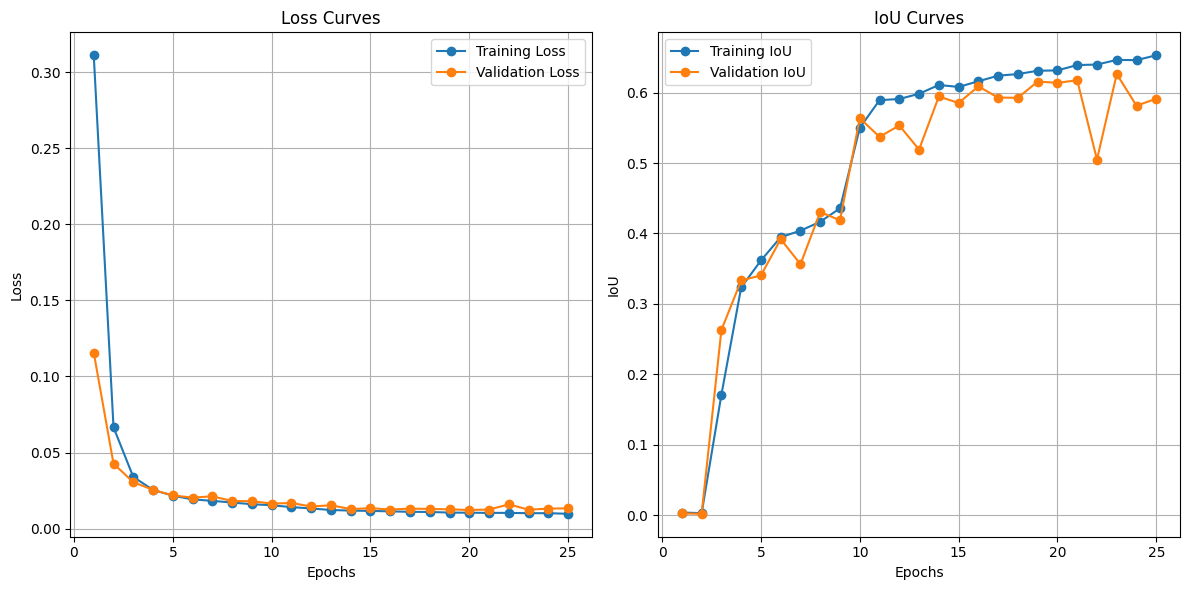

In [ ]:
# Plot the performance graphs
plt.figure(figsize=(12, 6))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# IoU Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_iou, label='Training IoU', marker='o')
plt.plot(epochs, val_iou, label='Validation IoU', marker='o')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('IoU Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()